In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [3]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(891, 15)


In [4]:
df.to_csv("titanic.csv", index=False)

print("Raw Titanic dataset saved as titanic.csv")

Raw Titanic dataset saved as titanic.csv


In [5]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None
         survived      pclass         age       sibsp       parch        fare
count  891

In [6]:
missing = df.isnull().mean() * 100

print("Missing values:")
print(missing[missing > 0])

Missing values:
age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


In [7]:
cleaned_df = df.copy()

In [8]:
missing = cleaned_df.isnull().mean() * 100

print("Missing percentage by column:")
print(missing[missing > 0])

Missing percentage by column:
age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


In [9]:
cleaned_df["age"] = cleaned_df["age"].fillna(
    cleaned_df["age"].median())

In [10]:
cleaned_df["embarked"] = cleaned_df["embarked"].fillna(
    cleaned_df["embarked"].mode()[0])

In [11]:
cleaned_df["embark_town"] = cleaned_df["embark_town"].fillna(
    cleaned_df["embark_town"].mode()[0])

In [12]:
cleaned_df["deck"] = cleaned_df["deck"].astype("object").fillna("Missing")

In [13]:
print("Missing values after cleaning:")
print(cleaned_df.isnull().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


### Missing Value Handling

The missing-value percentages were calculated before cleaning. Columns with less than 5% missing values would have their affected rows dropped, while columns with 5%–30% missing values were imputed. Columns with very high missingness were not imputed with an estimated value because doing so could introduce unreliable information.

- `age`: approximately 19.9% missing → median imputation because it falls within the 5%–30% range.
- `embarked`: approximately 0.2% missing → the affected rows could be dropped because the missing percentage is below 5%.
- `embark_town`: approximately 0.2% missing → the affected rows could be dropped because the missing percentage is below 5%.
- `deck`: approximately 77% missing → missing values were encoded as a separate `"Missing"` category rather than statistically imputing the deck.

This approach follows the specified missing-value threshold rule while avoiding unreliable imputation for the highly incomplete `deck` column.

In [15]:
# Save the cleaned dataset
cleaned_df.to_csv("titanic.csv", index=False)

print("Cleaned Titanic dataset saved successfully!")
print(cleaned_df.shape)

Cleaned Titanic dataset saved successfully!
(891, 15)


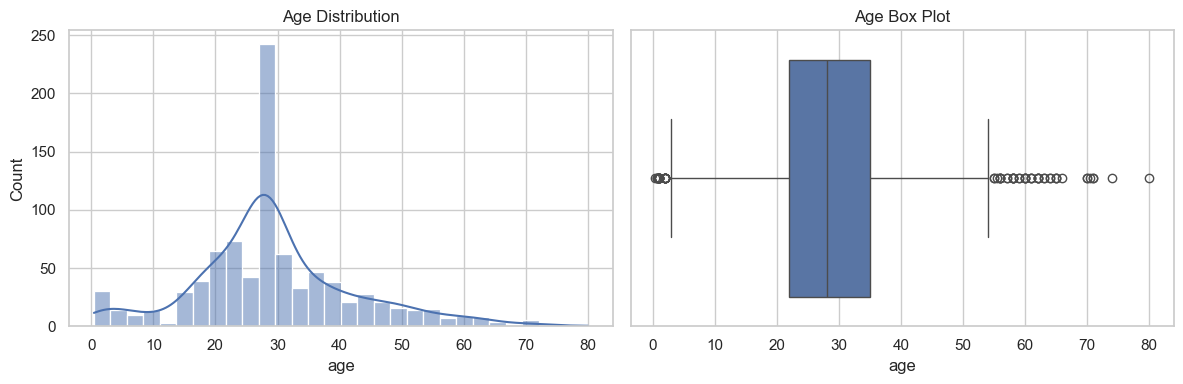

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(cleaned_df["age"], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.boxplot(x=cleaned_df["age"], ax=axes[1])
axes[1].set_title("Age Box Plot")

plt.tight_layout()
plt.show()

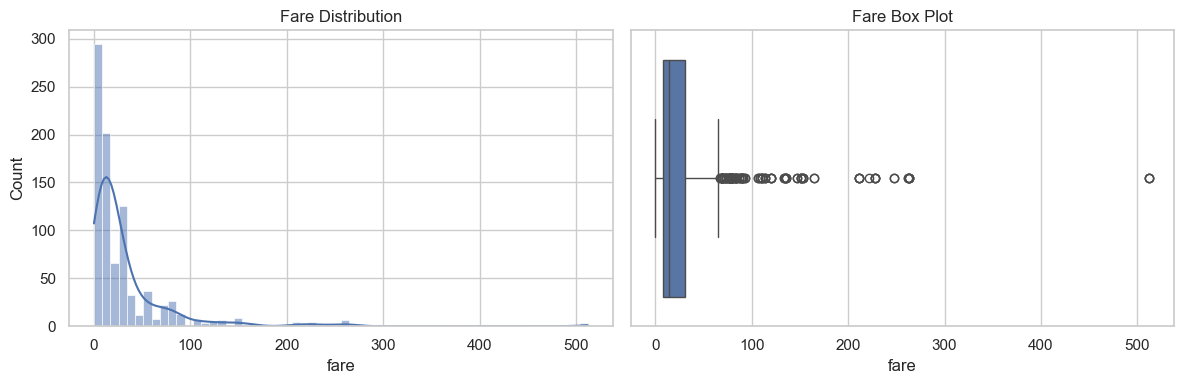

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(cleaned_df["fare"], kde=True, ax=axes[0])
axes[0].set_title("Fare Distribution")

sns.boxplot(x=cleaned_df["fare"], ax=axes[1])
axes[1].set_title("Fare Box Plot")

plt.tight_layout()
plt.show()

In [18]:
def find_outliers(column):
    Q1 = cleaned_df[column].quantile(0.25)
    Q3 = cleaned_df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = cleaned_df[
        (cleaned_df[column] < lower) |
        (cleaned_df[column] > upper)
    ]
    
    return Q1, Q3, IQR, lower, upper, len(outliers)


age_result = find_outliers("age")
fare_result = find_outliers("fare")

print("AGE")
print("Q1:", age_result[0])
print("Q3:", age_result[1])
print("IQR:", age_result[2])
print("Lower:", age_result[3])
print("Upper:", age_result[4])
print("Outliers:", age_result[5])

print("\nFARE")
print("Q1:", fare_result[0])
print("Q3:", fare_result[1])
print("IQR:", fare_result[2])
print("Lower:", fare_result[3])
print("Upper:", fare_result[4])
print("Outliers:", fare_result[5])

AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower: 2.5
Upper: 54.5
Outliers: 66

FARE
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower: -26.724
Upper: 65.6344
Outliers: 116


In [19]:
fare_mean = cleaned_df["fare"].mean()
fare_median = cleaned_df["fare"].median()
fare_mode = cleaned_df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.204207968574636
Fare Median: 14.4542
Fare Mode: 8.05


In [20]:
print("Fare Skewness:", cleaned_df["fare"].skew())

Fare Skewness: 4.787316519674893


### Fare Distribution Interpretation

The mean, median, and mode of `fare` are compared to understand the shape of the distribution. When the mean is greater than the median and the median is greater than the mode, the distribution is right-skewed. The positive skewness value and the ordering of the mean, median, and mode indicate that a relatively small number of passengers paid substantially higher fares.

In [21]:
survival_by_sex = cleaned_df.groupby("sex")["survived"].mean()

print("Survival Rate by Sex:")
print(survival_by_sex)

Survival Rate by Sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [22]:
survival_by_class = cleaned_df.groupby("pclass")["survived"].mean()

print("\nSurvival Rate by Pclass:")
print(survival_by_class)


Survival Rate by Pclass:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [23]:
survival_by_sex_class = cleaned_df.groupby(
    ["sex", "pclass"]
)["survived"].mean()

print("\nSurvival Rate by Sex and Pclass:")
print(survival_by_sex_class)


Survival Rate by Sex and Pclass:
sex     pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


In [24]:
female_first = cleaned_df[
    (cleaned_df["sex"] == "female") &
    (cleaned_df["pclass"] == 1)
]

male_third = cleaned_df[
    (cleaned_df["sex"] == "male") &
    (cleaned_df["pclass"] == 3)
]

print("Female + First Class:")
print(female_first["survived"].mean())

print("\nMale + Third Class:")
print(male_third["survived"].mean())

Female + First Class:
0.9680851063829787

Male + Third Class:
0.13544668587896252


In [26]:
corr_cols = ["survived","pclass","age","sibsp","parch","fare"]
corr_matrix = cleaned_df[corr_cols].corr()

print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500
age      -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688
sibsp    -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000


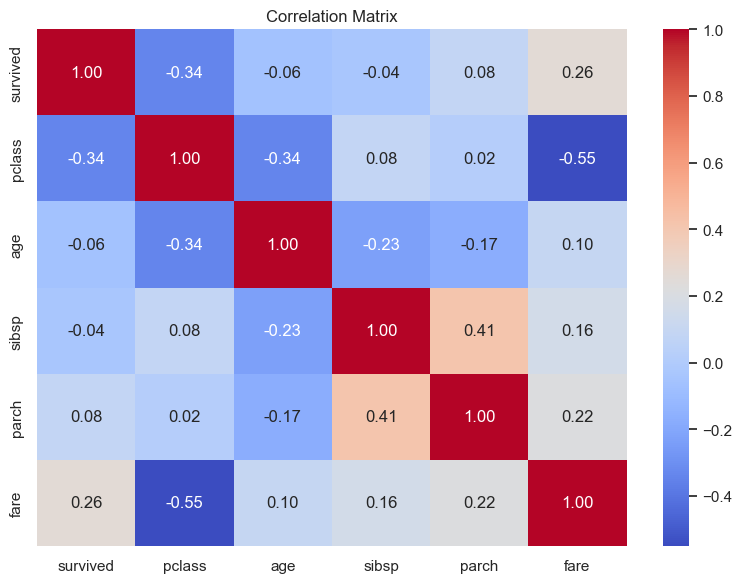

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [28]:
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack()

strongest = corr_pairs.abs().sort_values(ascending=False).head(2)

print("Two strongest correlations:")
print(strongest)

Two strongest correlations:
pclass  fare     0.549500
sibsp   parch    0.414838
dtype: float64


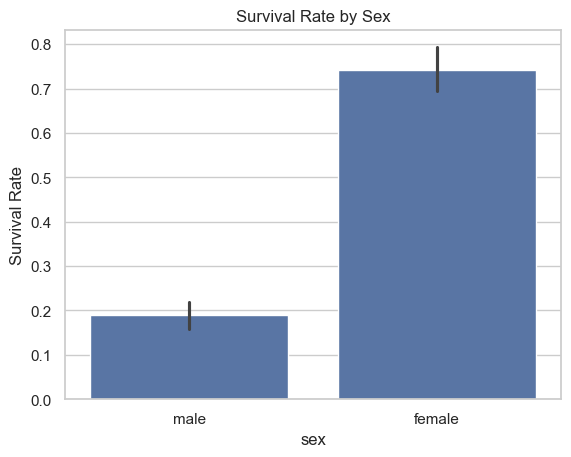

In [29]:
sns.barplot(
    data=cleaned_df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

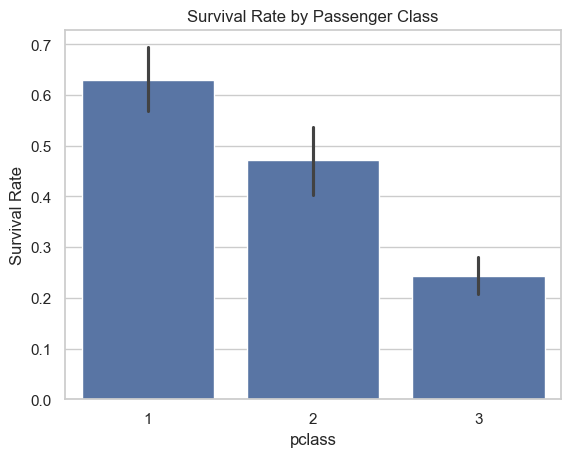

In [30]:
sns.barplot(
    data=cleaned_df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

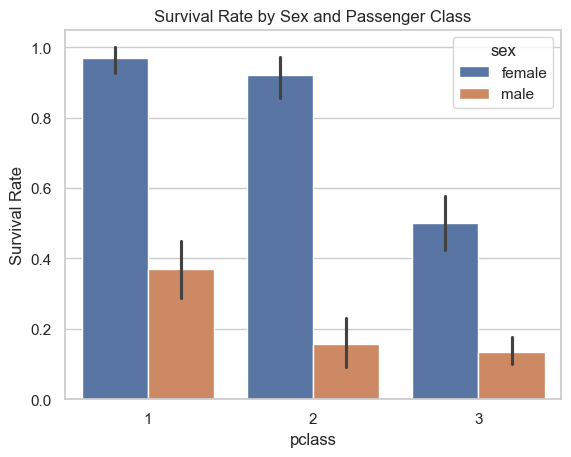

In [32]:
sns.barplot(data=cleaned_df,x="pclass",y="survived",hue="sex")

plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

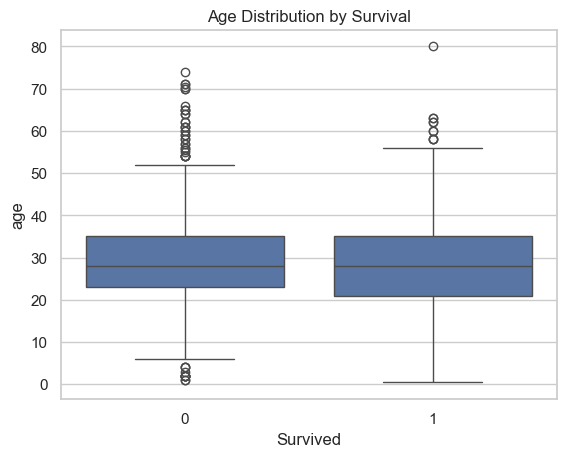

In [34]:
sns.boxplot(data=cleaned_df,x="survived",y="age")

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.show()

### Multivariate Data Story

**Chart 1 — Survival by Sex:**  
The survival rate differs substantially between male and female passengers. Female passengers had a higher survival rate than male passengers, showing that sex was strongly associated with survival.

**Chart 2 — Survival by Passenger Class:**  
Survival rates vary across passenger classes. Passengers in higher classes generally had higher survival rates than passengers in lower classes.

**Chart 3 — Sex and Passenger Class:**  
Combining sex and passenger class reveals a stronger pattern than looking at either variable alone. Female passengers generally had higher survival rates, while passengers in higher classes also tended to have better survival outcomes.

**Chart 4 — Age and Survival:**  
The age distributions of survivors and non-survivors show differences in their central tendency and spread. Age therefore provides additional information about survival, although it is not sufficient by itself to explain the outcome.

In [35]:
scaler = StandardScaler()

cleaned_df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(
    cleaned_df[["age", "fare"]]
)

print("Before standardization:")
print(cleaned_df[["age", "fare"]].mean())
print(cleaned_df[["age", "fare"]].std())

print("\nAfter standardization:")
print(cleaned_df[["age_scaled", "fare_scaled"]].mean())
print(cleaned_df[["age_scaled", "fare_scaled"]].std())

Before standardization:
age     29.361582
fare    32.204208
dtype: float64
age     13.019697
fare    49.693429
dtype: float64

After standardization:
age_scaled     2.272780e-16
fare_scaled    3.987333e-18
dtype: float64
age_scaled     1.000562
fare_scaled    1.000562
dtype: float64
